# Ising pseudo-likelihood fit for DGL FraudYelpDataset

We fit the three-relation model
$$
\mathbb P_{\beta,\gamma}(\sigma\mid X,G)
\propto
\exp\left\{
\sum_{r=1}^3 \beta_r \sum_{(i,j)\in E_r}\sigma_i\sigma_j
+2\sum_{i=1}^n \sigma_i X_i^\top\gamma
\right\},
\qquad \sigma_i\in\{-1,1\}.
$$

The full likelihood is not used, because the partition function is intractable on this graph. Instead, this notebook fits the maximum pseudo-likelihood estimator (MPLE). For node \(i\), define
$$
S_{ir}=\sum_{j:(j,i)\in E_r}\sigma_j .
$$
Then
$$
\mathbb P(\sigma_i=1\mid \sigma_{-i},X,G)
=
\operatorname{logit}^{-1}\left(
2\left[
\sum_{r=1}^3 \beta_r S_{ir}+2X_i^\top\gamma
\right]
\right).
$$

The DGL Fraud Yelp graph has three relations. In this notebook I use
$$
\beta_1=\beta_{\text{R-U-R}},\qquad
\beta_2=\beta_{\text{R-S-R}},\qquad
\beta_3=\beta_{\text{R-T-R}}.
$$


In [1]:
# If needed, install dependencies first. Pick the DGL wheel matching your PyTorch version.
# %pip install -q scikit-learn pandas
# %pip install -q dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html


In [2]:
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist


import dgl
from dgl.data import FraudYelpDataset


SEED = 717
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Load Fraud Yelp

DGL stores this as a one-node-type heterograph with relation names `net_rur`, `net_rsr`, and `net_rtr`. The original labels are \(0/1\); we convert them to \(\{-1,1\}\) by
$$
\sigma_i = 2y_i-1.
$$
Thus label \(1\) is treated as the positive fraud/spam class.


In [3]:
dataset = FraudYelpDataset(
    random_seed=SEED,
    train_size=0.7,
    val_size=0.1,
    verbose=True,
)

g = dataset[0]
print(g)
print("node types:", g.ntypes)
print("edge types:", g.etypes)
print("canonical edge types:", g.canonical_etypes)


Done loading data from cached files.
Graph(num_nodes={'review': 45954},
      num_edges={('review', 'net_rsr', 'review'): 6805486, ('review', 'net_rtr', 'review'): 1147232, ('review', 'net_rur', 'review'): 98630},
      metagraph=[('review', 'review', 'net_rsr'), ('review', 'review', 'net_rtr'), ('review', 'review', 'net_rur')])
node types: ['review']
edge types: ['net_rsr', 'net_rtr', 'net_rur']
canonical edge types: [('review', 'net_rsr', 'review'), ('review', 'net_rtr', 'review'), ('review', 'net_rur', 'review')]


In [4]:
def get_node_data(g, key, ntype=None):
    """Return node data tensor for a graph with one node type or a heterograph."""
    if ntype is None:
        if len(g.ntypes) != 1:
            raise ValueError("Pass ntype explicitly for a graph with multiple node types.")
        ntype = g.ntypes[0]
    try:
        value = g.ndata[key]
        if isinstance(value, dict):
            return value[ntype]
        return value
    except Exception:
        return g.nodes[ntype].data[key]


ntype = g.ntypes[0]

X_raw = get_node_data(g, "feature", ntype).float()
y01 = get_node_data(g, "label", ntype).long()
train_mask = get_node_data(g, "train_mask", ntype).bool()
val_mask = get_node_data(g, "val_mask", ntype).bool()
test_mask = get_node_data(g, "test_mask", ntype).bool()

sigma_all = 2.0 * y01.float() - 1.0

summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "n": [
        int(train_mask.sum()),
        int(val_mask.sum()),
        int(test_mask.sum()),
        int(y01.numel()),
    ],
    "positives": [
        int(y01[train_mask].sum()),
        int(y01[val_mask].sum()),
        int(y01[test_mask].sum()),
        int(y01.sum()),
    ],
})
summary["positive_rate"] = summary["positives"] / summary["n"]
summary


,split,n,positives,positive_rate
0,train,32167,4726,0.146921
1,validation,4595,651,0.141676
2,test,9192,1300,0.141427
3,all,45954,6677,0.145297


## Relation order

The estimator below uses the following order:
$$
(\beta_1,\beta_2,\beta_3)
=
(\beta_{\text{R-U-R}},\beta_{\text{R-S-R}},\beta_{\text{R-T-R}}).
$$

In DGL these are `net_rur`, `net_rsr`, and `net_rtr`.


In [5]:
EDGE_TYPES = ["net_rur", "net_rsr", "net_rtr"]
BETA_LABELS = [
    "beta_1: R-U-R / net_rur / same user",
    "beta_2: R-S-R / net_rsr / same product and same star",
    "beta_3: R-T-R / net_rtr / same product and same month",
]

missing = [e for e in EDGE_TYPES if e not in g.etypes]
if missing:
    raise ValueError(f"Missing expected edge types: {missing}. Present edge types: {g.etypes}")

for etype in EDGE_TYPES:
    print(f"{etype:8s}: {g.num_edges(etype=etype):,} directed edges")


net_rur : 98,630 directed edges
net_rsr : 6,805,486 directed edges
net_rtr : 1,147,232 directed edges


## Feature preprocessing

We standardize the 32 node features using only the training nodes and add an intercept column. This is just a reparametrization of the external-field term \(X_i^\top\gamma\). The printed `gamma_raw_scale` below converts the fitted coefficient back to the original feature scale.


In [6]:
def standardize_with_train_stats(X, train_mask, add_intercept=True, eps=1e-12):
    X = X.float()
    mean = X[train_mask].mean(dim=0)
    std = X[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
    X_std = (X - mean) / std
    if add_intercept:
        ones = torch.ones((X.shape[0], 1), dtype=X.dtype, device=X.device)
        X_aug = torch.cat([ones, X_std], dim=1)
    else:
        X_aug = X_std
    return X_aug, mean, std


X_aug, X_mean, X_std = standardize_with_train_stats(X_raw, train_mask, add_intercept=True)
print("X_raw shape:", tuple(X_raw.shape))
print("X_aug shape:", tuple(X_aug.shape))


X_raw shape: (45954, 32)
X_aug shape: (45954, 33)


## Build the local neighbor sums \(S_{ir}\)

For a fair supervised train/validation/test evaluation, validation and test labels should not be used in the local sums. Therefore the default below uses only training labels as observed spins; neighbors outside the training set contribute \(0\).

If you instead want the fully observed MPLE diagnostic, replace `SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = train_mask` by all `True`. That uses validation and test labels inside the covariates and is therefore not a fair node-classification evaluation.


In [7]:
SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = train_mask
# SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = torch.ones_like(train_mask, dtype=torch.bool)  # oracle diagnostic only

# To match the model exactly, use "none".
# If the optimization saturates because of very large degrees, try "degree";
# that fits a degree-normalized variant, not exactly the displayed model.
NEIGHBOR_NORMALIZATION = "degree"  # one of {"none", "degree", "sqrt_degree"}


@torch.no_grad()
def compute_relation_neighbor_sums(g, sigma_source, edge_types, normalize="none", device=None):
    """
    Return S with S[i, r] = sum_{j : (j,i) in E_r} sigma_source[j].

    The DGL fraud graphs are bidirected and have no self-loops, so incoming directed
    edges give the usual undirected-neighbor local field.
    """
    if device is None:
        device = sigma_source.device

    sigma_source = sigma_source.to(device).float()
    n = sigma_source.numel()
    cols = []

    for etype in edge_types:
        src, dst = g.edges(etype=etype)
        src = src.to(device)
        dst = dst.to(device)

        out = torch.zeros(n, dtype=torch.float32, device=device)
        out.index_add_(0, dst, sigma_source[src])

        if normalize in {"degree", "sqrt_degree"}:
            deg = torch.zeros(n, dtype=torch.float32, device=device)
            deg.index_add_(0, dst, torch.ones(dst.shape[0], dtype=torch.float32, device=device))
            if normalize == "degree":
                out = out / deg.clamp_min(1.0)
            else:
                out = out / deg.clamp_min(1.0).sqrt()
        elif normalize == "none":
            pass
        else:
            raise ValueError("normalize must be one of {'none', 'degree', 'sqrt_degree'}")

        cols.append(out)

    return torch.stack(cols, dim=1)


sigma_source = torch.zeros_like(sigma_all)
sigma_source[SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS] = sigma_all[SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS]

S_raw = compute_relation_neighbor_sums(
    g,
    sigma_source=sigma_source,
    edge_types=EDGE_TYPES,
    normalize=NEIGHBOR_NORMALIZATION,
    device=device,
).cpu()

S_raw_df = pd.DataFrame(S_raw[train_mask].numpy(), columns=EDGE_TYPES).describe().T
S_raw_df


,count,mean,std,min,25%,50%,75%,max
net_rur,32167.0,-0.321973,0.450760,-1.0,-0.750000,0.000000,0.000000,1.0
net_rsr,32167.0,-0.493501,0.163297,-1.0,-0.577982,-0.528689,-0.439697,1.0
net_rtr,32167.0,-0.487702,0.218061,-1.0,-0.613636,-0.500000,-0.388889,1.0


For numerical stability, we divide each \(S_{\cdot r}\) by its training-set standard deviation before optimization. This does not change the model class: after fitting, the notebook converts \(\beta\) back to the original scale.


In [8]:
eps = 1e-12
S_scale = S_raw[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
S_scaled = S_raw / S_scale

pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "S_train_std": S_scale.numpy(),
})


,edge_type,S_train_std
0,net_rur,0.450780
1,net_rsr,0.163295
2,net_rtr,0.218065


## MPLE model

The conditional log-odds used in the binary logistic regression is
$$
\log \frac{\mathbb P(\sigma_i=1\mid\sigma_{-i},X,G)}
{\mathbb P(\sigma_i=-1\mid\sigma_{-i},X,G)}
=
2\left[\sum_{r=1}^3\beta_r S_{ir}+2X_i^\top\gamma\right].
$$


In [9]:
class IsingPseudolikelihood(nn.Module):
    def __init__(self, n_features_aug, n_relations=3):
        super().__init__()
        self.beta = nn.Parameter(torch.zeros(n_relations))
        self.gamma = nn.Parameter(torch.zeros(n_features_aug))

    def logits(self, S_scaled, X_aug):
        # Local field:
        # H_i = sum_r beta_r S_ir + 2 X_i^T gamma.
        H = S_scaled @ self.beta + 2.0 * (X_aug @ self.gamma)
        # log odds P(sigma=+1)/P(sigma=-1) = 2 H_i.
        return 2.0 * H

    def forward(self, S_scaled, X_aug):
        return self.logits(S_scaled, X_aug)


def fit_mple(
    S_scaled,
    X_aug,
    y01,
    train_mask,
    l2_beta=1e-4,
    l2_gamma=1e-4,
    max_iter=200,
    pos_weight=None,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_scaled = S_scaled.to(device).float()
    X_aug = X_aug.to(device).float()
    y01 = y01.to(device).float()
    train_mask = train_mask.to(device).bool()

    model = IsingPseudolikelihood(
        n_features_aug=X_aug.shape[1],
        n_relations=S_scaled.shape[1],
    ).to(device)

    if pos_weight is not None:
        pos_weight_tensor = torch.tensor(float(pos_weight), device=device)
    else:
        pos_weight_tensor = None

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=max_iter,
        line_search_fn="strong_wolfe",
    )

    def objective():
        logits = model(S_scaled, X_aug)
        data_loss = F.binary_cross_entropy_with_logits(
            logits[train_mask],
            y01[train_mask],
            pos_weight=pos_weight_tensor,
        )
        penalty = 0.5 * l2_beta * (model.beta @ model.beta)
        # Do not penalize the intercept gamma[0].
        if model.gamma.numel() > 1:
            penalty = penalty + 0.5 * l2_gamma * (model.gamma[1:] @ model.gamma[1:])
        return data_loss + penalty

    def closure():
        optimizer.zero_grad(set_to_none=True)
        loss = objective()
        loss.backward()
        return loss

    optimizer.step(closure)

    with torch.no_grad():
        final_loss = objective().item()

    return model, final_loss


# Use the true MPLE by default. Setting USE_POS_WEIGHT=True changes the objective
# and may help classification under imbalance, but it is no longer the ordinary MPLE.
USE_POS_WEIGHT = False

y_train = y01[train_mask]
pos_weight = None
if USE_POS_WEIGHT:
    pos_weight = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
    print("Using pos_weight =", pos_weight)

model, final_loss = fit_mple(
    S_scaled=S_scaled,
    X_aug=X_aug,
    y01=y01,
    train_mask=train_mask,
    l2_beta=1e-4,
    l2_gamma=1e-4,
    max_iter=250,
    pos_weight=pos_weight,
    device=device,
)

print("Final regularized training objective:", final_loss)


Final regularized training objective: 0.24803654849529266


In [10]:
@torch.no_grad()
def convert_parameters_to_original_scale(model, S_scale, X_mean, X_std):
    """
    Convert beta back from S_scaled = S_raw / S_scale.

    The gamma conversion uses X_aug = [1, (X_raw - mean)/std].
    """
    beta_scaled = model.beta.detach().cpu()
    gamma_std_scale = model.gamma.detach().cpu()

    beta_original_scale = beta_scaled / S_scale.cpu()

    gamma_raw_scale = torch.empty_like(gamma_std_scale)
    gamma_raw_scale[1:] = gamma_std_scale[1:] / X_std.cpu()
    gamma_raw_scale[0] = gamma_std_scale[0] - (gamma_std_scale[1:] * X_mean.cpu() / X_std.cpu()).sum()

    return beta_scaled, beta_original_scale, gamma_std_scale, gamma_raw_scale


beta_scaled, beta_original_scale, gamma_std_scale, gamma_raw_scale = convert_parameters_to_original_scale(
    model, S_scale, X_mean, X_std
)

beta_df = pd.DataFrame({
    "parameter": BETA_LABELS,
    "estimate_on_scaled_S": beta_scaled.numpy(),
    "estimate_original_S_scale": beta_original_scale.numpy(),
})
beta_df


,parameter,estimate_on_scaled_S,estimate_original_S_scale
0,beta_1: R-U-R / net_rur / same user,1.203040,2.668794
1,beta_2: R-S-R / net_rsr / same product and sam...,0.214751,1.315111
2,beta_3: R-T-R / net_rtr / same product and sam...,0.050435,0.231286


In [11]:
gamma_df = pd.DataFrame({
    "parameter": ["gamma_intercept"] + [f"gamma_feature_{j}" for j in range(X_raw.shape[1])],
    "estimate_standardized_X_scale": gamma_std_scale.numpy(),
    "estimate_raw_X_scale": gamma_raw_scale.numpy(),
})
gamma_df.head(15)


,parameter,estimate_standardized_X_scale,estimate_raw_X_scale
0,gamma_intercept,-0.036151,-4.380375
1,gamma_feature_0,0.076706,0.263920
2,gamma_feature_1,0.009924,0.034350
3,gamma_feature_2,-0.053243,-0.188520
4,gamma_feature_3,-0.046773,-0.234216
5,gamma_feature_4,-0.033626,-0.229683
6,gamma_feature_5,-0.134024,-0.452309
7,gamma_feature_6,0.015447,0.050802
8,gamma_feature_7,-0.026118,-0.090394
9,gamma_feature_8,-0.055489,-0.192399


## Prediction and evaluation

The model gives
$$
\widehat p_i
=
\mathbb P(\sigma_i=1\mid X,G,\text{observed spins})
=
\operatorname{logit}^{-1}\left(
2\left[\sum_r\widehat\beta_r S_{ir}+2X_i^\top\widehat\gamma\right]
\right).
$$

Because this dataset is imbalanced, the threshold \(0.5\) is often not the most useful reporting threshold. The next cells report both threshold \(0.5\) and a threshold selected on validation data to maximize balanced accuracy.


In [12]:
@torch.no_grad()
def predict_prob(model, S_scaled, X_aug, device=None):
    if device is None:
        device = next(model.parameters()).device
    logits = model(S_scaled.to(device).float(), X_aug.to(device).float())
    return torch.sigmoid(logits).detach().cpu(), logits.detach().cpu()


prob, logits = predict_prob(model, S_scaled, X_aug, device=device)
prob[:10]


tensor([0.2431, 0.7209, 0.8483, 0.8062, 0.0971, 0.6925, 0.1081, 0.1324, 0.1314,
        0.1041])

In [13]:
def safe_auc(y_true, score):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def safe_ap(y_true, score):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return average_precision_score(y_true, score)


def evaluate_mask(name, mask, y01, prob, threshold=0.5):
    idx = mask.cpu().numpy().astype(bool)
    y_true = y01.cpu().numpy()[idx].astype(int)
    score = prob.cpu().numpy()[idx]
    y_pred = (score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return {
        "split": name,
        "threshold": threshold,
        "n": int(idx.sum()),
        "positive_rate": float(y_true.mean()),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_pos": precision_score(y_true, y_pred, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": safe_auc(y_true, score),
        "average_precision": safe_ap(y_true, score),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }


metrics_05 = pd.DataFrame([
    evaluate_mask("train", train_mask, y01, prob, threshold=0.5),
    evaluate_mask("validation", val_mask, y01, prob, threshold=0.5),
    evaluate_mask("test", test_mask, y01, prob, threshold=0.5),
])
metrics_05


,split,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,roc_auc,average_precision,tn,fp,fn,tp
0,train,0.5,32167,0.146921,0.897441,0.708511,0.760306,0.440965,0.558189,0.907930,0.684012,26784,657,2642,2084
1,validation,0.5,4595,0.141676,0.893580,0.691116,0.718919,0.408602,0.521058,0.908761,0.661468,3840,104,385,266
2,test,0.5,9192,0.141427,0.900131,0.705714,0.755348,0.434615,0.551758,0.909423,0.678851,7709,183,735,565


In [14]:
def select_threshold_on_validation(y01, prob, val_mask, objective="balanced_accuracy", n_grid=1001):
    y_true = y01.cpu().numpy()[val_mask.cpu().numpy().astype(bool)].astype(int)
    score = prob.cpu().numpy()[val_mask.cpu().numpy().astype(bool)]

    thresholds = np.linspace(0.0, 1.0, n_grid)
    best_t = 0.5
    best_value = -np.inf

    for t in thresholds:
        pred = (score >= t).astype(int)
        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif objective == "f1":
            value = f1_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("objective must be 'balanced_accuracy' or 'f1'")

        if value > best_value:
            best_value = value
            best_t = float(t)

    return best_t, best_value


best_t_balacc, best_val_balacc = select_threshold_on_validation(
    y01, prob, val_mask, objective="balanced_accuracy"
)
best_t_f1, best_val_f1 = select_threshold_on_validation(
    y01, prob, val_mask, objective="f1"
)

print("Best validation threshold for balanced accuracy:", best_t_balacc, "value:", best_val_balacc)
print("Best validation threshold for F1:", best_t_f1, "value:", best_val_f1)


Best validation threshold for balanced accuracy: 0.137 value: 0.8302977475751145
Best validation threshold for F1: 0.26 value: 0.6074766355140186


In [15]:
metrics_val_tuned = pd.DataFrame([
    evaluate_mask("train", train_mask, y01, prob, threshold=best_t_balacc),
    evaluate_mask("validation", val_mask, y01, prob, threshold=best_t_balacc),
    evaluate_mask("test", test_mask, y01, prob, threshold=best_t_balacc),
])
metrics_val_tuned


,split,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,roc_auc,average_precision,tn,fp,fn,tp
0,train,0.137,32167,0.146921,0.791681,0.822203,0.402757,0.865425,0.549694,0.907930,0.684012,21376,6065,636,4090
1,validation,0.137,4595,0.141676,0.795647,0.830298,0.399441,0.878648,0.549208,0.908761,0.661468,3084,860,79,572
2,test,0.137,9192,0.141427,0.797650,0.824654,0.400071,0.862308,0.546563,0.909423,0.678851,6211,1681,179,1121


## Optional: refit with degree-normalized local fields

The displayed model uses the raw sums \(S_{ir}\). On the Yelp graph, relation degrees can be large, so the raw model can have strong saturation. If you want the degree-normalized variant
$$
S_{ir}^{\mathrm{norm}}=\frac{1}{d_{ir}}\sum_{j:(j,i)\in E_r}\sigma_j,
$$
set `NEIGHBOR_NORMALIZATION = "degree"` near the top and rerun the notebook. This is not the same parameterization as the original Gibbs measure, but it is often numerically more stable for node classification.


## Optional: save fitted values


## MCMC posterior marginals for unweighted linear MPLE


In [16]:
# Model: h_i = sum_r beta_r S_ir + 2 X_i^T gamma, with S_ir built from unweighted neighbor sums.

@torch.no_grad()
def fitted_external_field(model, X_field, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    X_dev = X_field.to(device).float()
    if hasattr(model, "field"):
        field = model.field(X_dev)
    elif hasattr(model, "gamma"):
        field = X_dev @ model.gamma
    else:
        raise AttributeError("Model must provide either field(X) or gamma for the external field.")
    return field.detach().cpu().numpy().astype(np.float64)


def unique_undirected_pairs_from_dgl(g, etype, n):
    src, dst = g.edges(etype=etype)
    src, dst = src.detach().cpu().long(), dst.detach().cpu().long()
    mask = src != dst
    lo = torch.minimum(src[mask], dst[mask])
    hi = torch.maximum(src[mask], dst[mask])
    keys = torch.unique(lo * n + hi)
    return (keys // n).long(), (keys % n).long()


def initial_graph_field_from_csr(sigma_np, csr):
    indptr, col, coef = csr["indptr"], csr["col"], csr["coef"]
    graph_field = np.zeros(len(indptr) - 1, dtype=np.float64)
    for i in range(len(graph_field)):
        start, end = indptr[i], indptr[i + 1]
        if end > start:
            graph_field[i] = np.dot(coef[start:end], sigma_np[col[start:end]])
    return graph_field


def summarize_gibbs_samples(samples, y01, fixed_mask, ci_level=0.95):
    num_samples, n = samples.shape
    successes = (samples == 1).sum(axis=0).astype(np.float64)
    p_hat = successes / num_samples
    alpha0 = 0.5
    lower_q = (1.0 - ci_level) / 2.0
    upper_q = 1.0 - lower_q
    ci_lower = beta_dist.ppf(lower_q, successes + alpha0, num_samples - successes + alpha0)
    ci_upper = beta_dist.ppf(upper_q, successes + alpha0, num_samples - successes + alpha0)
    fixed_mask_np = fixed_mask.detach().cpu().numpy().astype(bool)
    observed_label_np = y01.detach().cpu().numpy().astype(int)
    p_fixed = observed_label_np.astype(np.float64)
    p_hat[fixed_mask_np] = p_fixed[fixed_mask_np]
    ci_lower[fixed_mask_np] = p_fixed[fixed_mask_np]
    ci_upper[fixed_mask_np] = p_fixed[fixed_mask_np]
    return pd.DataFrame({
        "P_sigma_plus_1": p_hat,
        f"P_sigma_plus_1_ci_lower_{ci_level:.2f}": ci_lower,
        f"P_sigma_plus_1_ci_upper_{ci_level:.2f}": ci_upper,
        "E_sigma": samples.mean(axis=0),
        "Var_sigma": samples.var(axis=0, ddof=1) if num_samples > 1 else np.zeros(n),
        "observed_label": observed_label_np,
        "fixed_in_mcmc": fixed_mask_np,
    })


def run_gibbs_from_csr(csr, b_hat, y01, fixed_mask, burn_in_sweeps=500, num_samples=1000, thinning=10, ci_level=0.95, seed=717):
    rng = np.random.default_rng(seed)
    y01_cpu = y01.detach().cpu().long()
    fixed_mask_cpu = fixed_mask.detach().cpu().bool()
    fixed_mask_np = fixed_mask_cpu.numpy().astype(bool)
    free_idx = np.flatnonzero(~fixed_mask_np)
    fixed_spin = (2 * y01_cpu.numpy() - 1).astype(np.int8)
    sigma_np = rng.choice([-1, 1], size=int(y01.numel())).astype(np.int8)
    sigma_np[fixed_mask_np] = fixed_spin[fixed_mask_np]
    graph_field = initial_graph_field_from_csr(sigma_np, csr)
    indptr, col, coef = csr["indptr"], csr["col"], csr["coef"]
    samples, trace = [], []
    total_sweeps = burn_in_sweeps + num_samples * thinning
    for sweep in range(total_sweeps):
        rng.shuffle(free_idx)
        for i in free_idx:
            h_i = graph_field[i] + 2.0 * b_hat[i]
            p_plus = 1.0 / (1.0 + np.exp(-np.clip(2.0 * h_i, -60.0, 60.0)))
            old_spin = int(sigma_np[i])
            new_spin = 1 if rng.random() < p_plus else -1
            if new_spin != old_spin:
                delta = new_spin - old_spin
                sigma_np[i] = new_spin
                start, end = indptr[i], indptr[i + 1]
                np.add.at(graph_field, col[start:end], delta * coef[start:end])
        sigma_np[fixed_mask_np] = fixed_spin[fixed_mask_np]
        if sweep >= burn_in_sweeps and (sweep - burn_in_sweeps) % thinning == 0:
            samples.append(sigma_np.copy())
        if sweep == 0 or (sweep + 1) % max(1, total_sweeps // 10) == 0:
            trace.append({"sweep": sweep + 1, "mean_sigma": float(sigma_np.mean()), "positive_rate": float((sigma_np == 1).mean())})
            print(f"sweep {sweep + 1:4d} / {total_sweeps}")
    samples = np.asarray(samples, dtype=np.int8)
    return {"samples": samples, "posterior": summarize_gibbs_samples(samples, y01_cpu, fixed_mask_cpu, ci_level), "trace": pd.DataFrame(trace), "last_sigma": sigma_np.copy()}

@torch.no_grad()
def build_unweighted_csr(model, g, edge_types, S_scale, neighbor_normalization="none", eps=1e-12):
    if neighbor_normalization not in {"none", "degree", "sqrt_degree"}:
        raise ValueError("neighbor_normalization must be 'none', 'degree', or 'sqrt_degree'.")
    n = int(g.num_nodes())
    beta_hat = model.beta.detach().cpu().float() / S_scale.detach().cpu().float().clamp_min(eps)
    degrees = torch.zeros((n, len(edge_types)), dtype=torch.float32)
    pairs = []
    for r, etype in enumerate(edge_types):
        i, j = unique_undirected_pairs_from_dgl(g, etype, n)
        pairs.append((i, j))
        ones = torch.ones(i.numel(), dtype=torch.float32)
        degrees[:, r].index_add_(0, i, ones); degrees[:, r].index_add_(0, j, ones)
    degrees = degrees.clamp_min(eps)
    row_parts, col_parts, coef_parts = [], [], []
    for r, (i, j) in enumerate(pairs):
        if neighbor_normalization == "none":
            scale_i = torch.ones_like(i, dtype=torch.float32); scale_j = torch.ones_like(j, dtype=torch.float32)
        elif neighbor_normalization == "degree":
            scale_i = 1.0 / degrees[i, r]; scale_j = 1.0 / degrees[j, r]
        else:
            scale_i = 1.0 / torch.sqrt(degrees[i, r]); scale_j = 1.0 / torch.sqrt(degrees[j, r])
        coef = beta_hat[r] * (scale_i + scale_j)
        row_parts.extend([i, j]); col_parts.extend([j, i]); coef_parts.extend([coef, coef])
    row, col, coef = torch.cat(row_parts).long(), torch.cat(col_parts).long(), torch.cat(coef_parts).float()
    order = torch.argsort(row); row, col, coef = row[order], col[order], coef[order]
    counts = torch.bincount(row, minlength=n)
    indptr = torch.zeros(n + 1, dtype=torch.long); indptr[1:] = torch.cumsum(counts, dim=0)
    return {"indptr": indptr.numpy().astype(np.int64), "col": col.numpy().astype(np.int64), "coef": coef.numpy().astype(np.float64), "degrees": degrees.numpy().astype(np.float64), "beta_original_scale": beta_hat.numpy().astype(np.float64)}


def gibbs_sample_unweighted_linear_mple(model, g, X_field, y01, fixed_mask, edge_types, S_scale, neighbor_normalization="none", burn_in_sweeps=500, num_samples=1000, thinning=10, ci_level=0.95, eps=1e-12, seed=717, device=None):
    b_hat = fitted_external_field(model, X_field, device=device)
    csr = build_unweighted_csr(model, g, edge_types, S_scale, neighbor_normalization, eps)
    out = run_gibbs_from_csr(csr, b_hat, y01, fixed_mask, burn_in_sweeps, num_samples, thinning, ci_level, seed)
    out.update({"beta_original_scale": csr["beta_original_scale"], "b_hat": b_hat, "degrees": csr["degrees"]})
    return out


In [16]:
MCMC_CONDITION_ON_TRAIN = True
MCMC_BURN_IN_SWEEPS = 500
MCMC_NUM_SAMPLES = 1000
MCMC_THINNING = 10
MCMC_CI_LEVEL = 0.95
MCMC_EPS = 1e-12
MCMC_SEED = 717

fixed_mask_mcmc = train_mask if MCMC_CONDITION_ON_TRAIN else torch.zeros_like(train_mask, dtype=torch.bool)


mcmc_results = gibbs_sample_unweighted_linear_mple(
    model=model, g=g, X_field=X_aug, y01=y01, fixed_mask=fixed_mask_mcmc,
    edge_types=EDGE_TYPES, S_scale=S_scale, neighbor_normalization=NEIGHBOR_NORMALIZATION,
    burn_in_sweeps=MCMC_BURN_IN_SWEEPS, num_samples=MCMC_NUM_SAMPLES,
    thinning=MCMC_THINNING, ci_level=MCMC_CI_LEVEL, eps=MCMC_EPS, seed=MCMC_SEED,
    device=device,
)

mcmc_results["trace"].tail()


sweep    1 / 10500
sweep 1050 / 10500
sweep 2100 / 10500
sweep 3150 / 10500
sweep 4200 / 10500
sweep 5250 / 10500
sweep 6300 / 10500
sweep 7350 / 10500
sweep 8400 / 10500
sweep 9450 / 10500
sweep 10500 / 10500


,sweep,mean_sigma,positive_rate
6,6300,-0.770640,0.114680
7,7350,-0.770292,0.114854
8,8400,-0.770727,0.114636
9,9450,-0.771250,0.114375
10,10500,-0.770510,0.114745


## Save MCMC outputs

Save posterior marginals, trace diagnostics, retained samples, and run metadata to Google Drive.


In [17]:
# Existing Google Drive MCMC output folder to load.
ROWNAME = "S_unweigh_linear"

LOAD_MCMC_OUTPUTS_FROM_GOOGLE_DRIVE = True
GOOGLE_DRIVE_MCMC_OUTPUT_DIR = "/content/drive/MyDrive/yelp/yelp_mcmc_outputs"

# Keep this False unless you intentionally want to overwrite the saved files.
SAVE_MCMC_OUTPUTS = False

if LOAD_MCMC_OUTPUTS_FROM_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    MCMC_OUTPUT_DIR = Path(GOOGLE_DRIVE_MCMC_OUTPUT_DIR)
else:
    MCMC_OUTPUT_DIR = Path("script/yelp/yelp_mcmc_outputs") if Path("script/yelp").exists() else Path("yelp_mcmc_outputs")

MCMC_OUTPUT_DIR = MCMC_OUTPUT_DIR / ROWNAME
if SAVE_MCMC_OUTPUTS:
    MCMC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

posterior_path = MCMC_OUTPUT_DIR / f"{ROWNAME}_posterior.csv"
trace_path = MCMC_OUTPUT_DIR / f"{ROWNAME}_trace.csv"
samples_path = MCMC_OUTPUT_DIR / f"{ROWNAME}_sigma_samples.npz"
metadata_path = MCMC_OUTPUT_DIR / f"{ROWNAME}_metadata.json"

if SAVE_MCMC_OUTPUTS:
    mcmc_results["posterior"].to_csv(posterior_path, index=True, index_label="node")
    mcmc_results["trace"].to_csv(trace_path, index=False)

    sample_payload = {
        "sigma_samples": mcmc_results["samples"],
        "samples": mcmc_results["samples"],  # backward-compatible alias
        "last_sigma": mcmc_results["last_sigma"],
    }
    for key in ["beta_hat", "beta_original_scale", "b_hat", "degrees"]:
        if key in mcmc_results:
            sample_payload[key] = mcmc_results[key]
    np.savez_compressed(samples_path, **sample_payload)

    mcmc_metadata = {
        "rowname": ROWNAME,
        "condition_on_train": MCMC_CONDITION_ON_TRAIN,
        "burn_in_sweeps": MCMC_BURN_IN_SWEEPS,
        "num_samples": MCMC_NUM_SAMPLES,
        "thinning": MCMC_THINNING,
        "ci_level": MCMC_CI_LEVEL,
        "eps": MCMC_EPS,
        "seed": MCMC_SEED,
        "posterior_path": str(posterior_path),
        "trace_path": str(trace_path),
        "samples_path": str(samples_path),
        "samples_shape": list(mcmc_results["samples"].shape),
        "samples_axis_0": "retained_mcmc_sample",
        "samples_axis_1": "node",
    }
    pd.Series(mcmc_metadata).to_json(metadata_path, indent=2)

    print("Saved MCMC posterior to", posterior_path)
    print("Saved MCMC trace to", trace_path)
    print("Saved full retained sigma vectors to", samples_path)
    print("sigma_samples shape:", mcmc_results["samples"].shape, "= (retained samples, nodes)")
    print("Saved MCMC metadata to", metadata_path)
else:
    print("SAVE_MCMC_OUTPUTS is False; existing MCMC files will only be read from", MCMC_OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SAVE_MCMC_OUTPUTS is False; existing MCMC files will only be read from /content/drive/MyDrive/yelp/yelp_mcmc_outputs/S_unweigh_linear


## Reload saved MCMC outputs

Load the saved posterior, trace, metadata, and full retained sigma vectors from the same output paths.


In [18]:
missing_mcmc_files = [path for path in [posterior_path, trace_path, samples_path, metadata_path] if not path.exists()]
if missing_mcmc_files:
    raise FileNotFoundError("Missing saved MCMC file(s): " + ", ".join(str(path) for path in missing_mcmc_files))

loaded_posterior_df = pd.read_csv(posterior_path, index_col="node")
loaded_trace_df = pd.read_csv(trace_path)
loaded_samples_npz = np.load(samples_path)
loaded_sigma_samples = loaded_samples_npz["sigma_samples"]
loaded_metadata = pd.read_json(metadata_path, typ="series")

mcmc_results = {
    "posterior": loaded_posterior_df,
    "trace": loaded_trace_df,
    "samples": loaded_sigma_samples,
}
for key in ["last_sigma", "beta_hat", "beta_original_scale", "b_hat", "degrees"]:
    if key in loaded_samples_npz.files:
        mcmc_results[key] = loaded_samples_npz[key]

print("Loaded posterior shape:", loaded_posterior_df.shape)
print("Loaded trace shape:", loaded_trace_df.shape)
print("Loaded sigma samples shape:", loaded_sigma_samples.shape)
print("Loaded metadata from", metadata_path)

loaded_metadata


Loaded posterior shape: (45954, 7)
Loaded trace shape: (11, 3)
Loaded sigma samples shape: (1000, 45954)
Loaded metadata from /content/drive/MyDrive/yelp/yelp_mcmc_outputs/S_unweigh_linear/S_unweigh_linear_metadata.json


,0
rowname,S_unweigh_linear
condition_on_train,True
burn_in_sweeps,500
num_samples,1000
thinning,10
ci_level,0.95
eps,0.0
seed,717
posterior_path,/content/drive/MyDrive/yelp/yelp_mcmc_outputs/...
trace_path,/content/drive/MyDrive/yelp/yelp_mcmc_outputs/...


In [19]:
posterior_df = mcmc_results["posterior"].copy()
posterior_df["train"] = train_mask.detach().cpu().numpy().astype(bool)
posterior_df["validation"] = val_mask.detach().cpu().numpy().astype(bool)
posterior_df["test"] = test_mask.detach().cpu().numpy().astype(bool)
posterior_df.loc[
    posterior_df["validation"] | posterior_df["test"],
    ["P_sigma_plus_1", "P_sigma_plus_1_ci_lower_0.95", "P_sigma_plus_1_ci_upper_0.95", "observed_label", "validation", "test"],
].head()


,P_sigma_plus_1,P_sigma_plus_1_ci_lower_0.95,P_sigma_plus_1_ci_upper_0.95,observed_label,validation,test
node,,,,,,
0,0.012,0.006576,0.020234,0,True,False
3,0.997,0.992016,0.999154,0,False,True
4,0.014,0.008046,0.022754,0,False,True
5,0.998,0.993600,0.999584,0,False,True
6,0.003,0.000846,0.007984,0,True,False


## MCMC sample covariance heatmap

Visualize posterior covariance between node spins using the retained Gibbs samples. The full Yelp node-by-node covariance matrix is too large to inspect directly, so this cell defaults to the most uncertain non-clamped nodes.


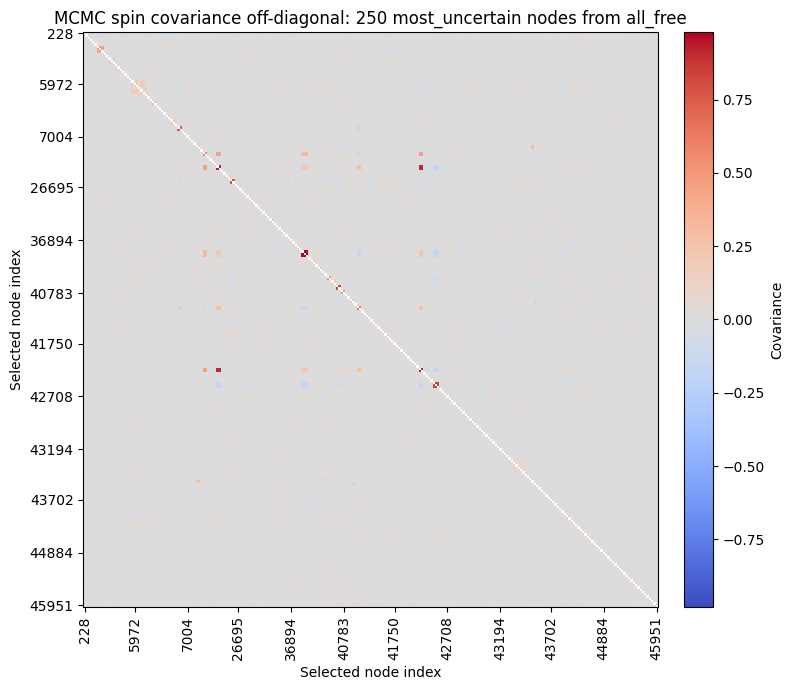

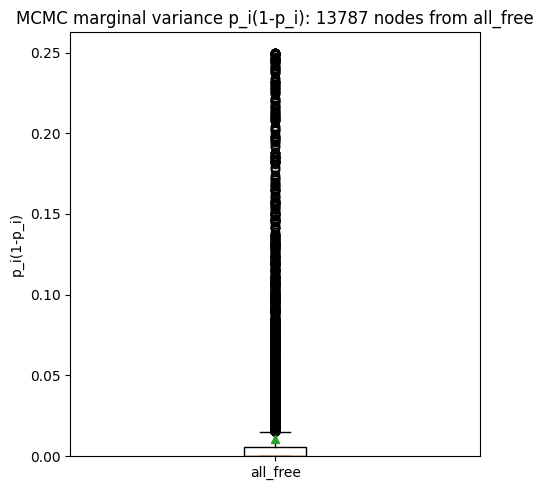

In [20]:
CORR_NODE_POOL = "all_free"  # one of {"all_free", "validation", "test"}
CORR_NODE_SELECTION = "most_uncertain"  # one of {"most_uncertain", "random", "first"}
CORR_MAX_NODES = 250
CORR_RANDOM_SEED = 717

samples_for_corr = mcmc_results["samples"].astype(np.float64)
posterior_for_corr = mcmc_results["posterior"].copy()

fixed_for_corr = posterior_for_corr["fixed_in_mcmc"].to_numpy().astype(bool)
val_for_corr = val_mask.detach().cpu().numpy().astype(bool)
test_for_corr = test_mask.detach().cpu().numpy().astype(bool)

if CORR_NODE_POOL == "all_free":
    pool_mask = ~fixed_for_corr
elif CORR_NODE_POOL == "validation":
    pool_mask = val_for_corr & ~fixed_for_corr
elif CORR_NODE_POOL == "test":
    pool_mask = test_for_corr & ~fixed_for_corr
else:
    raise ValueError("CORR_NODE_POOL must be 'all_free', 'validation', or 'test'.")

candidate_nodes = np.flatnonzero(pool_mask)
if candidate_nodes.size == 0:
    raise ValueError("No non-clamped nodes available for the selected correlation pool.")

k = min(CORR_MAX_NODES, candidate_nodes.size)
if CORR_NODE_SELECTION == "most_uncertain":
    p_hat_for_corr = posterior_for_corr["P_sigma_plus_1"].to_numpy()
    uncertainty = p_hat_for_corr[candidate_nodes] * (1.0 - p_hat_for_corr[candidate_nodes])
    selected_nodes = candidate_nodes[np.argsort(uncertainty)[-k:]]
elif CORR_NODE_SELECTION == "random":
    rng = np.random.default_rng(CORR_RANDOM_SEED)
    selected_nodes = rng.choice(candidate_nodes, size=k, replace=False)
elif CORR_NODE_SELECTION == "first":
    selected_nodes = candidate_nodes[:k]
else:
    raise ValueError("CORR_NODE_SELECTION must be 'most_uncertain', 'random', or 'first'.")

selected_nodes = np.sort(selected_nodes)
selected_samples = samples_for_corr[:, selected_nodes]
node_std = selected_samples.std(axis=0)
nonconstant = node_std > 0
selected_nodes = selected_nodes[nonconstant]
selected_samples = selected_samples[:, nonconstant]

if selected_nodes.size < 2:
    raise ValueError("Need at least two nonconstant selected nodes to compute a correlation matrix.")

mean_sigma = selected_samples.mean(axis=0)
mean_outer = selected_samples.T @ selected_samples / selected_samples.shape[0]
cov_matrix = mean_outer - np.outer(mean_sigma, mean_sigma)
cov_matrix_offdiag = cov_matrix.copy()
np.fill_diagonal(cov_matrix_offdiag, np.nan)

fig, ax = plt.subplots(figsize=(8, 7))
vmax = np.nanmax(np.abs(cov_matrix_offdiag))
vmax = 0.01 if not np.isfinite(vmax) or vmax == 0 else vmax
im = ax.imshow(cov_matrix_offdiag, cmap="vlag" if "sns" in globals() else "coolwarm", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_title(f"MCMC spin covariance off-diagonal: {selected_nodes.size} {CORR_NODE_SELECTION} nodes from {CORR_NODE_POOL}")
ax.set_xlabel("Selected node index")
ax.set_ylabel("Selected node index")

max_ticks = 12
tick_positions = np.linspace(0, selected_nodes.size - 1, min(max_ticks, selected_nodes.size), dtype=int)
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels(selected_nodes[tick_positions], rotation=90)
ax.set_yticklabels(selected_nodes[tick_positions])

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Covariance")
plt.tight_layout()
plt.show()

VAR_NODE_POOL = globals().get("CORR_NODE_POOL", "all_free")
posterior_for_variance = mcmc_results["posterior"].copy()
fixed_for_variance = posterior_for_variance["fixed_in_mcmc"].to_numpy().astype(bool)
val_for_variance = val_mask.detach().cpu().numpy().astype(bool)
test_for_variance = test_mask.detach().cpu().numpy().astype(bool)
p_hat_all = posterior_for_variance["P_sigma_plus_1"].to_numpy()

if VAR_NODE_POOL == "all_free":
    pool_mask = ~fixed_for_variance
elif VAR_NODE_POOL == "validation":
    pool_mask = val_for_variance & ~fixed_for_variance
elif VAR_NODE_POOL == "test":
    pool_mask = test_for_variance & ~fixed_for_variance
else:
    raise ValueError("VAR_NODE_POOL must be 'all_free', 'validation', or 'test'.")

variance_nodes = np.flatnonzero(pool_mask)
if variance_nodes.size == 0:
    raise ValueError("No non-clamped nodes available for the selected variance pool.")

marginal_variance_all = p_hat_all * (1.0 - p_hat_all)
node_variance = marginal_variance_all[variance_nodes]

fig, ax = plt.subplots(figsize=(5, 5))
ax.boxplot(
    node_variance,
    vert=True,
    showmeans=True,
    flierprops={"marker": "o", "markersize": 2, "markerfacecolor": "none", "markeredgecolor": "black", "alpha": 0.25},
)
ax.set_title(f"MCMC marginal variance p_i(1-p_i): {variance_nodes.size} nodes from {VAR_NODE_POOL}")
ax.set_xticks([1])
ax.set_xticklabels([VAR_NODE_POOL])
ax.set_ylabel("p_i(1-p_i)")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


In [18]:
posterior_df = mcmc_results["posterior"].copy()
if "P_sigma_plus_1" in posterior_df.columns:
    prob_col = "P_sigma_plus_1"
elif "P_label_1" in posterior_df.columns:
    prob_col = "P_label_1"
elif "p_hat_sigma_plus_1" in posterior_df.columns:
    prob_col = "p_hat_sigma_plus_1"
else:
    raise ValueError("Could not find marginal probability column in posterior_df.")

p_mcmc = posterior_df[prob_col].to_numpy()
y_true_all = y01.detach().cpu().numpy().astype(int)
val_idx = val_mask.detach().cpu().numpy().astype(bool)
test_idx = test_mask.detach().cpu().numpy().astype(bool)


def compute_binary_metrics(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    y_pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    out = {
        "threshold_value": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_pos": precision_score(y_true, y_pred, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }
    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan
    return out


def select_threshold_from_validation(y_val, score_val, objective="f1", n_grid=1001):
    best_t, best_value = 0.5, -np.inf
    for t in np.linspace(0.0, 1.0, n_grid):
        pred = (score_val >= t).astype(int)
        if objective == "f1":
            value = f1_score(y_val, pred, zero_division=0)
        elif objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_val, pred)
        else:
            raise ValueError("objective must be 'f1' or 'balanced_accuracy'.")
        if value > best_value:
            best_t, best_value = float(t), value
    return best_t, best_value


best_t_mcmc_f1, best_val_f1_mcmc = select_threshold_from_validation(
    y_val=y_true_all[val_idx],
    score_val=p_mcmc[val_idx],
    objective="f1",
    n_grid=1001,
)
best_t_mcmc_balacc, best_val_balacc_mcmc = select_threshold_from_validation(
    y_val=y_true_all[val_idx],
    score_val=p_mcmc[val_idx],
    objective="balanced_accuracy",
    n_grid=1001,
)

mcmc_thresholds = {
    "0.5": 0.5,
    "best_f1": best_t_mcmc_f1,
    "best_balanced_accuracy": best_t_mcmc_balacc,
}

mcmc_metrics = pd.DataFrame([
    {
        "threshold_type": threshold_type,
        **compute_binary_metrics(
            y_true=y_true_all[test_idx],
            score=p_mcmc[test_idx],
            threshold=threshold_value,
        ),
    }
    for threshold_type, threshold_value in mcmc_thresholds.items()
])

mcmc_metrics


,threshold_type,threshold_value,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision
0,0.5,0.500,9192,0.141427,0.883268,0.597909,0.887372,0.200000,0.326428,7859,33,1040,260,0.894814,0.648328
1,best_f1,0.013,9192,0.141427,0.870648,0.788135,0.533862,0.673077,0.595441,7128,764,425,875,0.894814,0.648328
2,best_balanced_accuracy,0.006,9192,0.141427,0.810705,0.820691,0.415709,0.834615,0.554987,6367,1525,215,1085,0.894814,0.648328


In [19]:
# Edit ROWNAME before running if you want a custom label in the CSV.
ROWNAME = "S_unweigh_linear"

# For Colab, set SAVE_TO_GOOGLE_DRIVE=True and edit GOOGLE_DRIVE_MCMC_METRICS_CSV_PATH.
SAVE_TO_GOOGLE_DRIVE = True
GOOGLE_DRIVE_MCMC_METRICS_CSV_PATH = "/content/drive/MyDrive/yelp/yelp_mcmc_metrics.csv"

if SAVE_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    METRICS_CSV_PATH = Path(GOOGLE_DRIVE_MCMC_METRICS_CSV_PATH)
else:
    METRICS_CSV_PATH = Path("script/yelp/yelp_mcmc_metrics.csv") if Path("script/yelp").exists() else Path("yelp_mcmc_metrics.csv")

OUTPUT_COLUMNS = [
    "rowname",
    "threshold_type",
    "threshold_value",
    "n",
    "positive_rate",
    "accuracy",
    "balanced_accuracy",
    "precision_pos",
    "recall_pos",
    "f1_pos",
    "roc_auc",
    "average_precision",
    "tn",
    "fp",
    "fn",
    "tp",
]


def append_mcmc_metric_rows(rowname, metrics_frame, csv_path=METRICS_CSV_PATH):
    csv_path = Path(csv_path)
    frame = metrics_frame.copy()
    frame["rowname"] = rowname
    saved = frame.reindex(columns=OUTPUT_COLUMNS)

    csv_path.parent.mkdir(parents=True, exist_ok=True)
    if csv_path.exists():
        existing = pd.read_csv(csv_path)
        if list(existing.columns) == OUTPUT_COLUMNS:
            saved = pd.concat([existing, saved], ignore_index=True)
        else:
            print(f"Existing CSV at {csv_path} has different columns; replacing it with test-only MCMC metrics.")

    saved.to_csv(csv_path, index=False)
    print(f"Saved {len(frame)} test MCMC metric rows to {csv_path}")
    return saved.tail(len(frame))


saved_metric_rows = append_mcmc_metric_rows(ROWNAME, mcmc_metrics)
saved_metric_rows


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved 3 test MCMC metric rows to /content/drive/MyDrive/yelp/yelp_mcmc_metrics.csv


,rowname,threshold_type,threshold_value,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,roc_auc,average_precision,tn,fp,fn,tp
15,S_unweigh_linear,0.5,0.500,9192,0.141427,0.883268,0.597909,0.887372,0.200000,0.326428,0.894814,0.648328,7859,33,1040,260
16,S_unweigh_linear,best_f1,0.013,9192,0.141427,0.870648,0.788135,0.533862,0.673077,0.595441,0.894814,0.648328,7128,764,425,875
17,S_unweigh_linear,best_balanced_accuracy,0.006,9192,0.141427,0.810705,0.820691,0.415709,0.834615,0.554987,0.894814,0.648328,6367,1525,215,1085


In [20]:
results = {
    "edge_types": EDGE_TYPES,
    "beta_scaled": beta_scaled.numpy().tolist(),
    "beta_original_scale": beta_original_scale.numpy().tolist(),
    "gamma_standardized_X_scale": gamma_std_scale.numpy().tolist(),
    "gamma_raw_X_scale": gamma_raw_scale.numpy().tolist(),
    "neighbor_normalization": NEIGHBOR_NORMALIZATION,
    "source_labels": "train_mask_only" if torch.equal(SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS, train_mask) else "custom",
    "threshold_05_metrics": metrics_05.to_dict(orient="records"),
    "threshold_val_balacc": best_t_balacc,
    "threshold_val_balacc_metrics": metrics_val_tuned.to_dict(orient="records"),
    "mcmc_condition_on_train": MCMC_CONDITION_ON_TRAIN,
    "mcmc_threshold_05": 0.5,
    "mcmc_threshold_best_f1": best_t_mcmc_f1,
    "mcmc_best_validation_f1": best_val_f1_mcmc,
    "mcmc_threshold_best_balanced_accuracy": best_t_mcmc_balacc,
    "mcmc_best_validation_balanced_accuracy": best_val_balacc_mcmc,
    "mcmc_metrics": mcmc_metrics.to_dict(orient="records"),
}

pd.Series(results)


,0
edge_types,"[net_rur, net_rsr, net_rtr]"
beta_scaled,"[1.2030397653579712, 0.2147509753704071, 0.050..."
beta_original_scale,"[2.6687943935394287, 1.315110683441162, 0.2312..."
gamma_standardized_X_scale,"[-0.03615090996026993, 0.07670632004737854, 0...."
gamma_raw_X_scale,"[-4.380375385284424, 0.26392030715942383, 0.03..."
neighbor_normalization,degree
source_labels,train_mask_only
threshold_05_metrics,"[{'split': 'train', 'threshold': 0.5, 'n': 321..."
threshold_val_balacc,0.137
threshold_val_balacc_metrics,"[{'split': 'train', 'threshold': 0.137, 'n': 3..."
